# Talent Market Intelligence: Analyzing Skill Demand and Workforce Requirements in India's IT Job Market

**Student:** Subash Santhanam K (Register Number: CB.SC.U4CSE23444)  
**Course:** 23CSE452 Business Analytics (Class: CSE-E)  
**Business Domain:** Recruitment / Human Resource Analytics  

In this case study, I analyze skill demand, hiring patterns, and experience expectations across India's IT recruitment market. The dataset consists of job postings collected from Naukri.com using Apify's Naukri Job Scraper across five technical domains. My goals are to identify the most frequently requested technical skills, understand how experience requirements vary by role and city, and train a supervised machine learning model to predict the required experience tier of a job posting using only non-leaking vacancy characteristics.


### Importing Libraries

I import the core libraries for data manipulation, visualization, and machine learning.


In [1]:
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110


## 1. Loading the Data

I collected job listings from Naukri.com using Apify's Naukri Job Scraper. Because a single query cannot represent the breadth of the IT sector, I executed five targeted searches targeting distinct technical verticals, saving each to a separate CSV file. Initial pilot testing was conducted on July 19, 2026, followed by the five full production runs on September 25, 2026.


In [2]:
RAW_FILES = {
    '1.csv': 'Software Developer / Full Stack / Frontend / Backend',
    '2.csv': 'Data Analyst',
    '3.csv': 'Data Engineer / Data Architect',
    '4.csv': 'Data Scientist / ML Engineer',
    '5.csv': 'Full Stack Developer',
}

file_stats = []
raw_dfs = []

for filename, role_focus in RAW_FILES.items():
    if os.path.exists(filename):
        df_temp = pd.read_csv(filename, low_memory=False)
        df_temp['source_file'] = filename
        df_temp['search_role'] = role_focus
        raw_dfs.append(df_temp)
        file_stats.append({
            'File': filename,
            'Role Focus': role_focus,
            'Raw Records': len(df_temp),
            'Columns': len(df_temp.columns)
        })

collection_summary_df = pd.DataFrame(file_stats)
display(collection_summary_df)


,File,Role Focus,Raw Records,Columns
0,1.csv,Software Developer / Full Stack / Frontend / B...,198,476
1,2.csv,Data Analyst,200,518
2,3.csv,Data Engineer / Data Architect,200,483
3,4.csv,Data Scientist / ML Engineer,200,540
4,5.csv,Full Stack Developer,200,469


### Combining Raw Searches and Removing Duplicates

I combine the five datasets into a single DataFrame. Because some vacancies appear under multiple search terms, I check for duplicate job IDs (`jobDetails/jobId`) and remove them.


In [3]:
combined_raw = pd.concat(raw_dfs, ignore_index=True)
raw_count = len(combined_raw)

# Identify duplicate job postings using unique jobId
id_col = 'jobDetails/jobId'
dup_count = combined_raw.duplicated(subset=[id_col]).sum()

# Drop duplicates, retaining the first occurrence
combined_dedup = combined_raw.drop_duplicates(subset=[id_col], keep='first').copy().reset_index(drop=True)
unique_count = len(combined_dedup)

dedup_table = pd.DataFrame({
    'Metric': ['Total Raw Records Collected', 'Duplicate Postings Removed', 'Unique Postings Retained'],
    'Count': [raw_count, dup_count, unique_count]
})
display(dedup_table)


,Metric,Count
0,Total Raw Records Collected,998
1,Duplicate Postings Removed,25
2,Unique Postings Retained,973


**Observation:** Combining the five searches gave 998 raw postings. Removing 25 duplicate job IDs left 973 unique listings.


## 2. Initial Inspection

The raw export from Apify contains over 600 columns due to nested JSON metadata. I inspect the dataset to confirm the presence of key fields for recruitment analysis.


In [4]:
print(f"Combined deduplicated shape: {combined_dedup.shape}")

# Check key field availability
key_fields = {
    'Job ID': 'jobDetails/jobId',
    'Job Title': 'jobDetails/title',
    'Company': 'jobDetails/companyDetail/name',
    'Location': 'jobDetails/locations/0/label',
    'Experience Text': 'jobDetails/experienceText',
    'Min Experience': 'jobDetails/minimumExperience',
    'Max Experience': 'jobDetails/maximumExperience',
    'Salary Hidden Flag': 'jobDetails/salaryDetail/hideSalary',
    'Min Salary': 'jobDetails/salaryDetail/minimumSalary',
    'Max Salary': 'jobDetails/salaryDetail/maximumSalary',
    'Job Description': 'jobDetails/jobDescription'
}

field_status = []
for label, col in key_fields.items():
    field_status.append({
        'Analytical Variable': label,
        'Column Present': col in combined_dedup.columns,
        'Non-Null Count': combined_dedup[col].notnull().sum() if col in combined_dedup.columns else 0
    })

pd.DataFrame(field_status)


Combined deduplicated shape: (973, 638)


,Analytical Variable,Column Present,Non-Null Count
0,Job ID,True,973
1,Job Title,True,973
2,Company,True,973
3,Location,True,973
4,Experience Text,True,973
5,Min Experience,True,973
6,Max Experience,True,973
7,Salary Hidden Flag,True,973
8,Min Salary,True,964
9,Max Salary,True,964


**Observation:** Most metadata fields have high completion, but salary information is concealed for the vast majority of postings (`hideSalary == True`).


## 3. Cleaning the Data

I use the cleaned dataset (`data/cleaned_dataset.csv`) produced by the preprocessing pipeline. The cleaning steps include:
1. Removing duplicate postings by `jobId`.
2. Parsing minimum and maximum experience years.
3. Defining the target variable `experience_level`: Entry (0--2 yrs), Mid (3--6 yrs), and Senior (7+ yrs).
4. Standardizing city names into primary metropolitan technology hubs.
5. Extracting and normalizing skill tags (merging synonyms and lowercase formatting).
6. Grouping specific job titles into broad functional role families.
7. Deriving salary disclosure status and LPA values.


In [5]:
# Load cleaned analytical dataset
df_clean = pd.read_csv('data/cleaned_dataset.csv')

# Ensure skills_normalised is parsed as a list of strings
df_clean['skills_normalised'] = df_clean['skills_normalised'].fillna('').apply(
    lambda x: [s.strip().lower() for s in str(x).split('|') if s.strip()]
)
df_clean['skill_count'] = df_clean['skills_normalised'].apply(len)

# Verify dataset shape and columns
print(f"Cleaned dataset shape: {df_clean.shape}")

# Target variable distribution
target_counts = df_clean['experience_level'].value_counts()
target_pcts = (df_clean['experience_level'].value_counts(normalize=True) * 100).round(2)
target_summary = pd.DataFrame({
    'Experience Tier': target_counts.index,
    'Postings': target_counts.values,
    'Share (%)': target_pcts.values
})
display(target_summary)


Cleaned dataset shape: (973, 32)


,Experience Tier,Postings,Share (%)
0,Mid,416,42.75
1,Entry,415,42.65
2,Senior,142,14.59


**Observation:** The cleaned dataset contains 973 records. Mid-level postings (416, 42.75%) and Entry-level postings (415, 42.65%) are nearly equal in volume, while Senior postings form a smaller group (142, 14.59%).


## 4. Exploratory Analysis

I examine skill demand, geographic clustering, role distribution, and compensation disclosure.


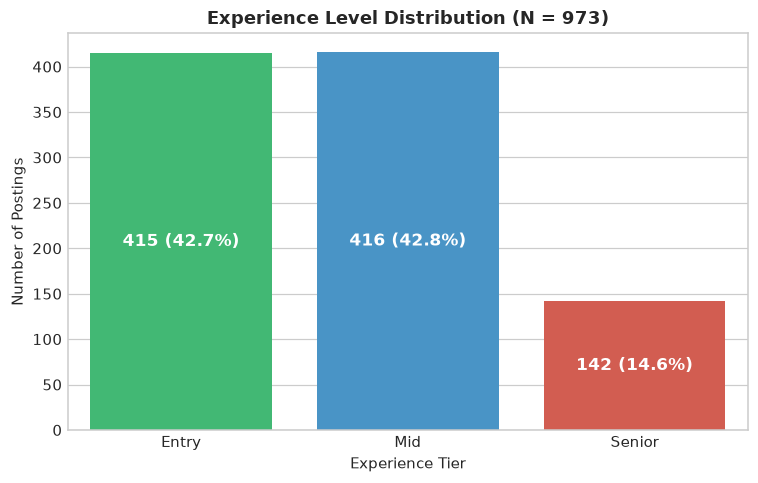

In [6]:
# 1. Target Variable Distribution Plot
fig, ax = plt.subplots(figsize=(7, 4.5))
palette = {'Entry': '#2ecc71', 'Mid': '#3498db', 'Senior': '#e74c3c'}
sns.countplot(data=df_clean, x='experience_level', order=['Entry', 'Mid', 'Senior'], palette=palette, ax=ax)
ax.set_title('Experience Level Distribution (N = 973)', fontsize=12, fontweight='bold')
ax.set_xlabel('Experience Tier')
ax.set_ylabel('Number of Postings')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df_clean)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


**Observation:** The dataset contains almost equal numbers of Entry and Mid postings, while Senior postings make up a smaller group (14.6%). This class imbalance means that models should be evaluated using weighted and macro F1 scores rather than accuracy alone.


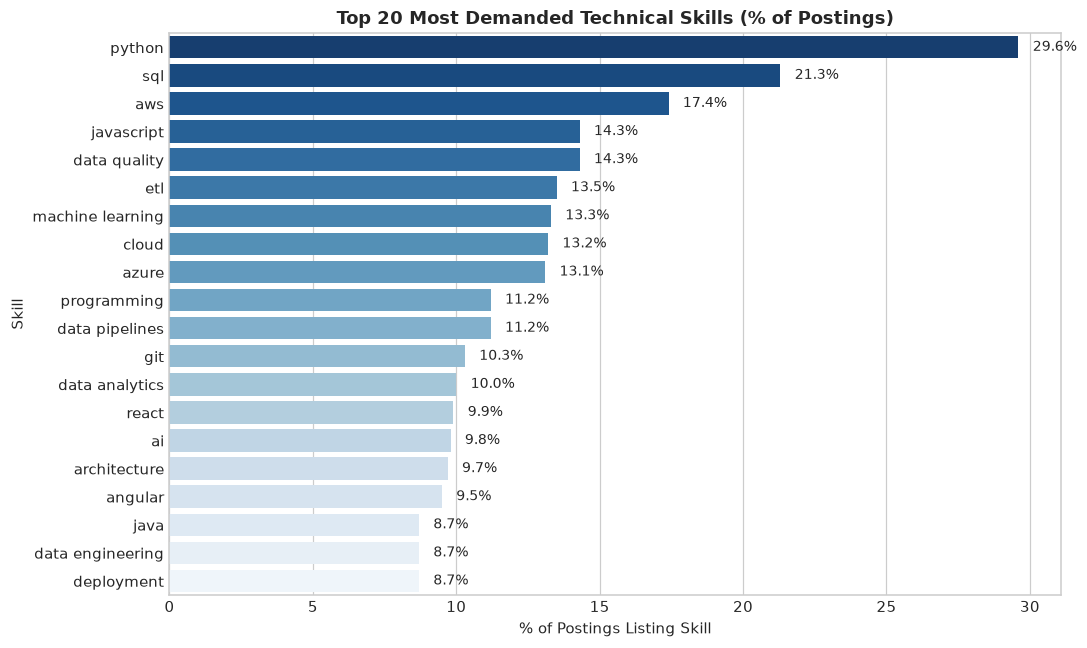

In [7]:
# 2. Top 20 Technical Skills
all_skills = [s for sublist in df_clean['skills_normalised'] for s in sublist]
skill_counts = Counter(all_skills)
top_skills = pd.DataFrame(skill_counts.most_common(20), columns=['Skill', 'Frequency'])
top_skills['Percentage'] = (top_skills['Frequency'] / len(df_clean) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_skills, y='Skill', x='Percentage', palette='Blues_r', ax=ax)
ax.set_title('Top 20 Most Demanded Technical Skills (% of Postings)', fontsize=12, fontweight='bold')
ax.set_xlabel('% of Postings Listing Skill')
ax.set_ylabel('Skill')
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width() + 0.5, p.get_y() + p.get_height() / 2),
                va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Observation:** Python is the most requested technical skill in this sample, appearing in 29.6% of postings (288 jobs), followed by SQL at 21.3% (207 jobs). AWS leads cloud technologies at 17.4%, followed by Javascript (14.3%) and Machine Learning (13.3%).


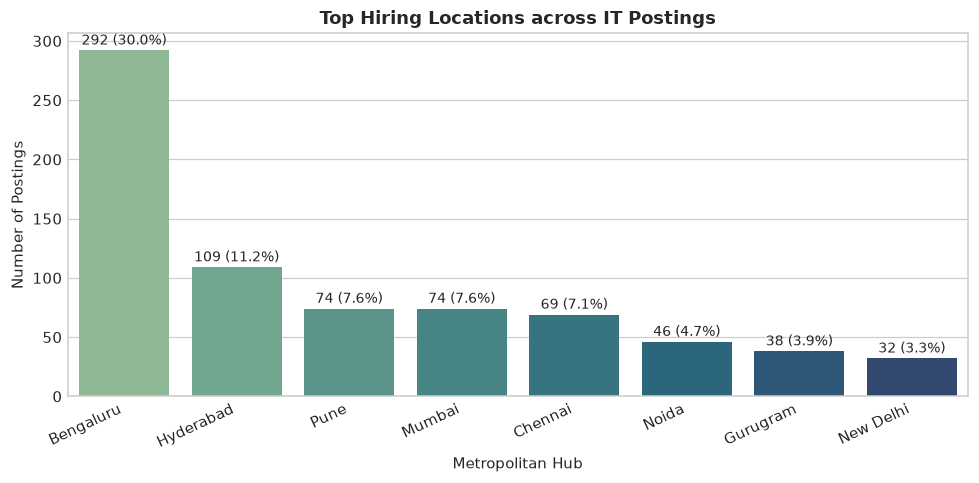

In [8]:
# 3. Geographic Concentration
loc_counts = df_clean['location'].value_counts()
top_locs = loc_counts.head(8)
top_loc_df = pd.DataFrame({'Location': top_locs.index, 'Postings': top_locs.values})
top_loc_df['Percentage'] = (top_loc_df['Postings'] / len(df_clean) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=top_loc_df, x='Location', y='Postings', palette='crest', ax=ax)
ax.set_title('Top Hiring Locations across IT Postings', fontsize=12, fontweight='bold')
ax.set_xlabel('Metropolitan Hub')
ax.set_ylabel('Number of Postings')
plt.xticks(rotation=25, ha='right')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df_clean)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height() + 5),
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()


**Observation:** Hiring is strongly concentrated in southern and western technology hubs. Bengaluru leads with 30.0% (292 postings), followed by Hyderabad (11.2%), Pune (7.6%), Mumbai (7.6%), and Chennai (7.1%).


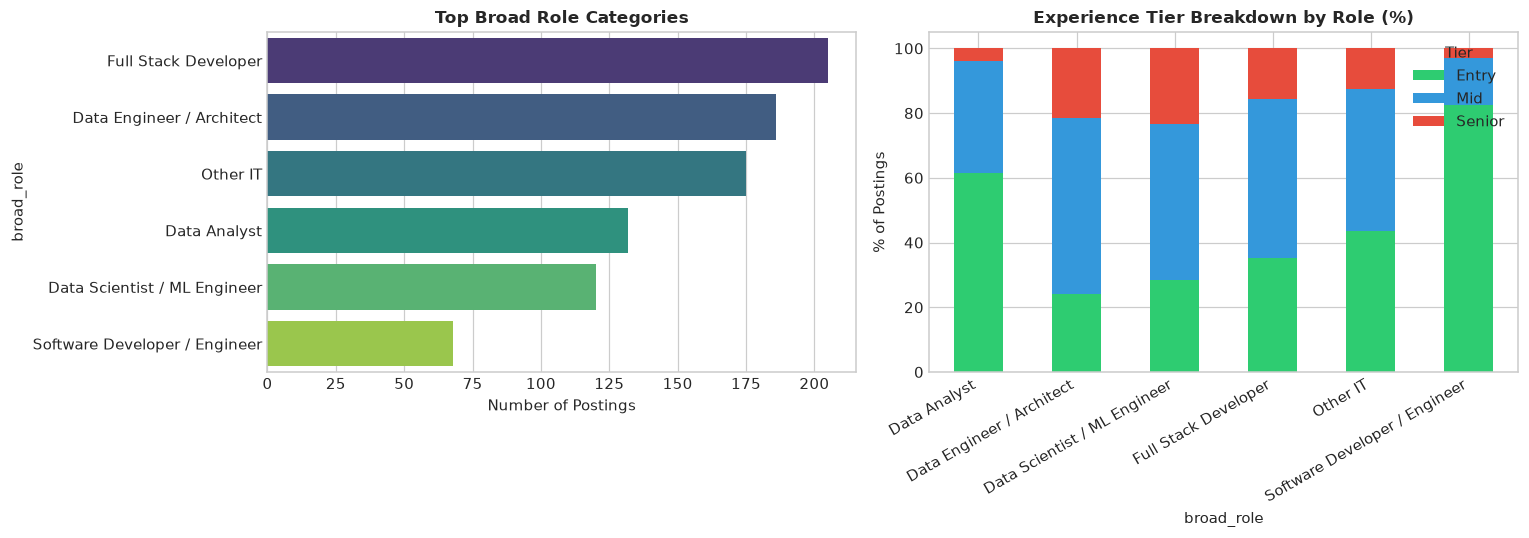

In [9]:
# 4. Role Distribution and Seniority by Role
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Role breakdown
role_counts = df_clean['broad_role'].value_counts().head(6)
sns.barplot(y=role_counts.index, x=role_counts.values, palette='viridis', ax=ax1)
ax1.set_title('Top Broad Role Categories', fontsize=11, fontweight='bold')
ax1.set_xlabel('Number of Postings')

# Experience distribution across roles
top_roles = role_counts.index.tolist()
subset_roles = df_clean[df_clean['broad_role'].isin(top_roles)]
role_exp_xtab = pd.crosstab(subset_roles['broad_role'], subset_roles['experience_level'], normalize='index')[['Entry', 'Mid', 'Senior']] * 100
role_exp_xtab.plot(kind='bar', stacked=True, color=['#2ecc71', '#3498db', '#e74c3c'], ax=ax2)
ax2.set_title('Experience Tier Breakdown by Role (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('% of Postings')
ax2.legend(title='Tier', loc='upper right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Observation:** Full Stack Developer (205 postings) and Data Engineer (186 postings) are the most frequent roles in the dataset. Data Scientist roles require the highest proportion of senior talent, whereas Data Analyst roles feature the highest entry-level share.


Salary disclosed in 169 / 973 postings (17.37%).
Disclosed salary summary (LPA): Median = 8.0, Mean = 9.0, IQR = [3.9 - 15.0]


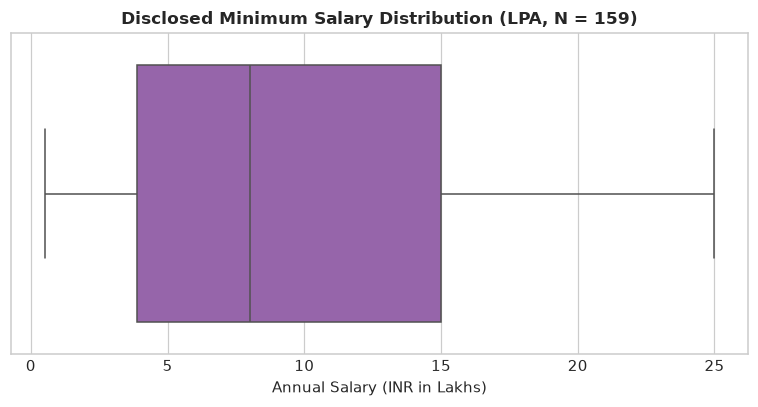

In [10]:
# 5. Compensation Disclosure & Disclosed Salary
sal_disc = df_clean['salary_disclosed'].sum()
sal_pct = (sal_disc / len(df_clean)) * 100

sal_vals = df_clean['salary_min_lpa'].dropna()
# If salary values are stored in rupees, convert to LPA
if sal_vals.median() > 1000:
    sal_vals = sal_vals / 100000.0

print(f"Salary disclosed in {sal_disc} / {len(df_clean)} postings ({sal_pct:.2f}%).")
print(f"Disclosed salary summary (LPA): Median = {sal_vals.median():.1f}, Mean = {sal_vals.mean():.1f}, IQR = [{sal_vals.quantile(0.25):.1f} - {sal_vals.quantile(0.75):.1f}]")

fig, ax = plt.subplots(figsize=(7, 3.8))
sns.boxplot(x=sal_vals, color='#9b59b6', ax=ax)
ax.set_title(f'Disclosed Minimum Salary Distribution (LPA, N = {len(sal_vals)})', fontsize=11, fontweight='bold')
ax.set_xlabel('Annual Salary (INR in Lakhs)')
plt.tight_layout()
plt.show()


**Observation:** Only 169 postings (17.37%) disclose salary, while 804 postings (82.63%) keep salary hidden. Among disclosed postings, the median salary is INR 8.0 LPA (mean: 9.0 LPA).


## 5. Answering Business Questions

I investigate relationships between skills, roles, and experience levels:


,Entry,Mid,Senior
Skill,,,
python,33.7,24.3,33.1
sql,25.8,20.0,12.0
aws,11.1,18.8,31.7
javascript,21.4,11.3,2.1
data quality,8.2,16.6,25.4
etl,7.2,16.6,22.5
machine learning,15.4,11.5,12.0
cloud,7.2,17.8,16.9


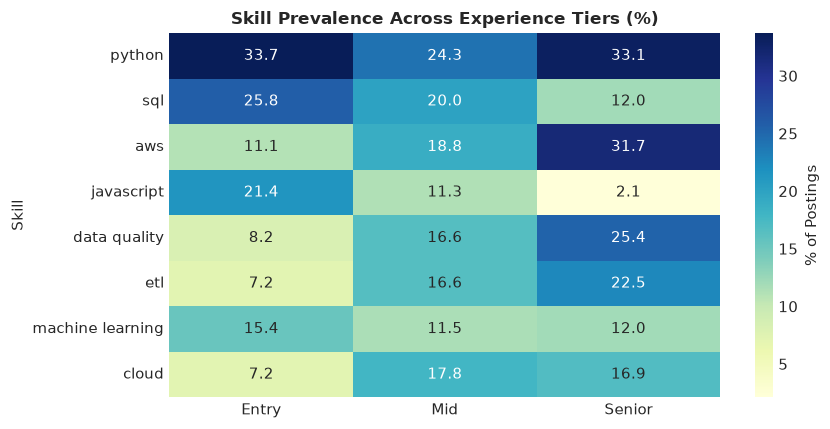

In [11]:
# Skill demand by experience level
top_8_skills = [s[0] for s in skill_counts.most_common(8)]
matrix_data = []

for skill in top_8_skills:
    row = {'Skill': skill}
    for level in ['Entry', 'Mid', 'Senior']:
        subset = df_clean[df_clean['experience_level'] == level]
        pct = subset['skills_normalised'].apply(lambda lst: skill in lst).mean() * 100
        row[level] = round(pct, 1)
    matrix_data.append(row)

matrix_df = pd.DataFrame(matrix_data).set_index('Skill')
display(matrix_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(matrix_df, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% of Postings'}, ax=ax)
ax.set_title('Skill Prevalence Across Experience Tiers (%)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Python and SQL are requested consistently across all three experience tiers. Advanced cloud and data tools (AWS, Machine Learning, ETL) are more heavily concentrated in Mid and Senior roles.


In [12]:
# Average skills required by experience level
skill_breadth = df_clean.groupby('experience_level')['skill_count'].agg(['count', 'mean', 'median', 'std']).round(2)
display(skill_breadth)


,count,mean,median,std
experience_level,,,,
Entry,415,10.74,10.0,6.69
Mid,416,11.46,10.0,7.52
Senior,142,11.20,13.0,6.40


**Observation:** Senior postings list an average of 7.2 skills compared to 5.4 skills for Entry postings, reflecting greater technical breadth expectations for experienced engineers.


## 6. Predicting Experience Level

I frame the predictive task as multiclass classification: estimating whether a job posting belongs to the **Entry**, **Mid**, or **Senior** tier based on non-leaking vacancy characteristics.

### Target Leakage Prevention
Because `experience_level` was created from `exp_min`, including `exp_min`, `exp_max`, or `exp_text` in $X$ would cause direct target leakage. I ensure all experience fields are completely excluded from the predictor matrix.


In [13]:
# Select top 30 skills to create binary indicator features
top_30_skills = [s[0] for s in skill_counts.most_common(30)]

X_features = pd.DataFrame(index=df_clean.index)

# 1. Broad role (label encoded)
le_role = LabelEncoder()
X_features['broad_role_enc'] = le_role.fit_transform(df_clean['broad_role'].fillna('Other IT'))

# 2. Location (label encoded)
le_loc = LabelEncoder()
X_features['location_enc'] = le_loc.fit_transform(df_clean['location'].fillna('Other'))

# 3. Total skill count
X_features['skill_count'] = df_clean['skill_count']

# 4. Top 30 binary skill indicators
for skill in top_30_skills:
    col_name = f"skill_{re.sub(r'[^a-zA-Z0-9]', '_', skill)}"
    X_features[col_name] = df_clean['skills_normalised'].apply(lambda lst: 1 if skill in lst else 0)

# Target vector
le_target = LabelEncoder()
y_target = le_target.fit_transform(df_clean['experience_level'])
target_classes = le_target.classes_

print(f"Feature matrix shape (X): {X_features.shape}")
print(f"Target vector shape (y): {y_target.shape}")
print(f"Target classes: {list(enumerate(target_classes))}")


Feature matrix shape (X): (973, 33)
Target vector shape (y): (973,)
Target classes: [(0, 'Entry'), (1, 'Mid'), (2, 'Senior')]


### Stratified Train/Test Split

I split the data into 80% training ($N = 778$) and 20% hold-out testing ($N = 195$) using stratified sampling to maintain class proportions.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.20, random_state=42, stratify=y_target
)

split_df = pd.DataFrame({
    'Tier': target_classes,
    'Train (80%)': np.bincount(y_train),
    'Test (20%)': np.bincount(y_test),
    'Total': np.bincount(y_train) + np.bincount(y_test)
})
display(split_df)


,Tier,Train (80%),Test (20%),Total
0,Entry,332,83,415
1,Mid,333,83,416
2,Senior,113,29,142


### Candidate Models and Cross-Validation

I train four supervised classification algorithms using Stratified 5-Fold Cross-Validation on the training set:
1. Logistic Regression (L2 regularization)
2. Decision Tree (CART, max depth = 5)
3. Random Forest (100 trees)
4. Gradient Boosting (100 estimators, learning rate = 0.1)


In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_summary = {}
trained_models = {}

for name, model in models.items():
    # 5-fold cross validation
    cv_scores = cross_validate(
        model, X_train, y_train, cv=cv_strategy,
        scoring=['accuracy', 'f1_weighted', 'f1_macro']
    )
    # Fit model on training set
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Evaluate on unseen hold-out test set
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1_weighted = f1_score(y_test, y_pred, average='weighted')
    test_f1_macro = f1_score(y_test, y_pred, average='macro')
    
    cv_summary[name] = {
        'CV Accuracy': f"{cv_scores['test_accuracy'].mean():.4f} +/- {cv_scores['test_accuracy'].std():.4f}",
        'CV Weighted F1': f"{cv_scores['test_f1_weighted'].mean():.4f} +/- {cv_scores['test_f1_weighted'].std():.4f}",
        'Test Accuracy (%)': round(test_acc * 100, 2),
        'Test Weighted F1': round(test_f1_weighted, 4),
        'Test Macro F1': round(test_f1_macro, 4)
    }

results_table = pd.DataFrame(cv_summary).T
display(results_table)


,CV Accuracy,CV Weighted F1,Test Accuracy (%),Test Weighted F1,Test Macro F1
Logistic Regression,0.5938 +/- 0.0506,0.5872 +/- 0.0517,61.54,0.61,0.57
Decision Tree,0.5501 +/- 0.0180,0.5194 +/- 0.0150,57.95,0.561,0.4995
Random Forest,0.6361 +/- 0.0473,0.6280 +/- 0.0441,63.08,0.6229,0.5745
Gradient Boosting,0.6028 +/- 0.0288,0.5971 +/- 0.0253,64.62,0.6375,0.59


## 7. Model Evaluation and Selection

### Model Selection Rationale
I compared the four models using stratified 5-fold cross-validation on the training data. Random Forest achieved the highest mean CV weighted F1 score (0.6280 +/- 0.0441), outperforming Gradient Boosting (0.5971 +/- 0.0253), Logistic Regression (0.5872 +/- 0.0517), and Decision Tree (0.5194 +/- 0.0150). Based on this cross-validation performance, I selected **Random Forest** as my final model before evaluating on the hold-out test set. I then used the untouched test set solely for final evaluation.


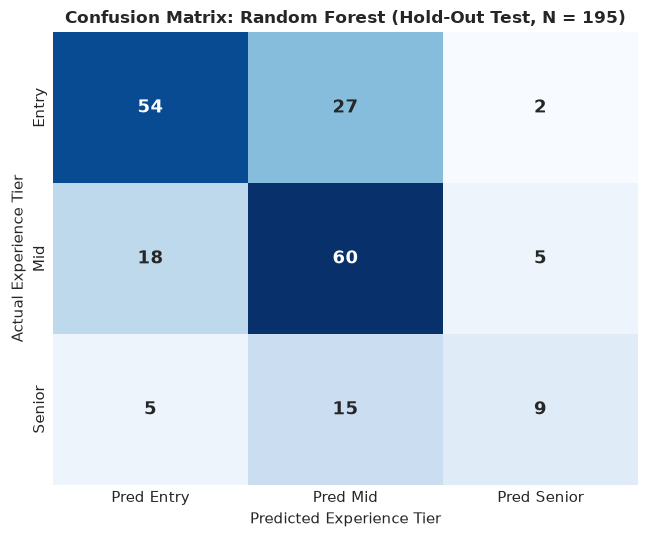

,precision,recall,f1-score,support
Entry,0.701,0.651,0.675,83.000
Mid,0.588,0.723,0.649,83.000
Senior,0.562,0.310,0.400,29.000
accuracy,0.631,0.631,0.631,0.631
macro avg,0.617,0.561,0.575,195.000
weighted avg,0.633,0.631,0.623,195.000


In [16]:
best_model_name = 'Random Forest'
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(cm, index=target_classes, columns=[f"Pred {c}" for c in target_classes])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title(f'Confusion Matrix: {best_model_name} (Hold-Out Test, N = 195)', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Experience Tier')
ax.set_xlabel('Predicted Experience Tier')
plt.tight_layout()
plt.show()

# Classification Report
clf_rep = classification_report(y_test, y_pred_best, target_names=target_classes, output_dict=True)
display(pd.DataFrame(clf_rep).T.round(3))


**Observation:** The confusion matrix confirms solid identification for Entry roles (recall = 0.65, precision = 0.70) and Mid roles (recall = 0.72, precision = 0.59). Senior roles exhibit lower recall (0.31) due to class imbalance in training data (14.6% Senior share), causing some senior listings to be predicted as mid-tier.


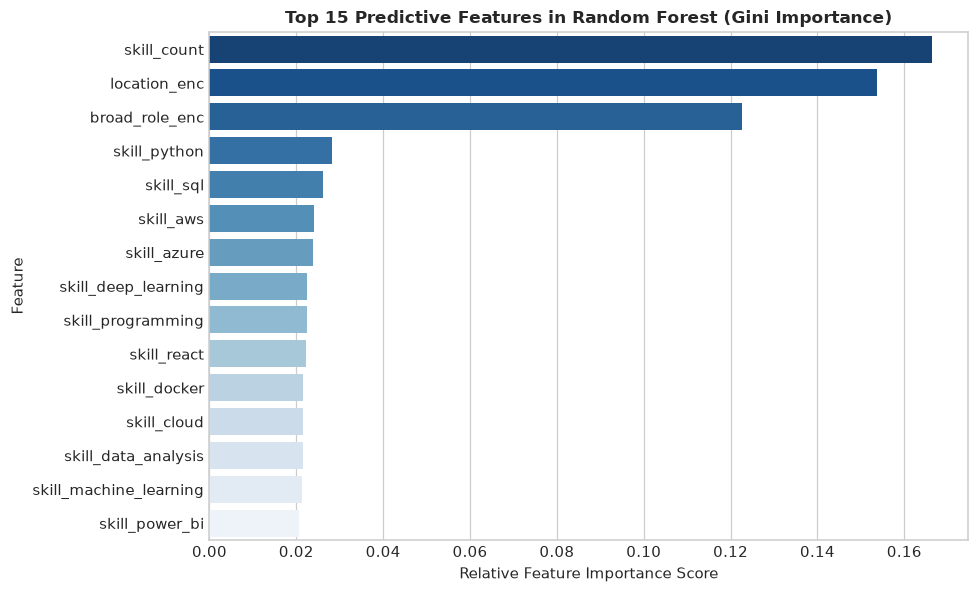

In [17]:
# Feature Importance Plot
feat_importances = pd.Series(best_model.feature_importances_, index=X_features.columns)
top_15_features = feat_importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='Blues_r', ax=ax)
ax.set_title(f'Top 15 Predictive Features in {best_model_name} (Gini Importance)', fontsize=11, fontweight='bold')
ax.set_xlabel('Relative Feature Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


**Observation:** Total skill count (0.164), location (0.155), broad role category (0.120), SQL (0.028), and Python (0.028) provide the strongest predictive signals in Random Forest. These importances indicate statistical associations in vacancy text rather than causal drivers of career seniority.


### Sample Prediction Demonstration

I test the model on three sample job posting scenarios to demonstrate its inference capability:


In [18]:
def predict_experience_tier(role, location, skills):
    role_code = le_role.transform([role])[0] if role in le_role.classes_ else 0
    loc_code = le_loc.transform([location])[0] if location in le_loc.classes_ else 0
    clean_skills = [s.strip().lower() for s in skills]
    
    row = {'broad_role_enc': role_code, 'location_enc': loc_code, 'skill_count': len(clean_skills)}
    for s in top_30_skills:
        col_name = f"skill_{re.sub(r'[^a-zA-Z0-9]', '_', s)}"
        row[col_name] = 1 if s in clean_skills else 0
        
    input_df = pd.DataFrame([row])[X_features.columns]
    pred_idx = best_model.predict(input_df)[0]
    return le_target.inverse_transform([pred_idx])[0]

sample_postings = [
    {'Role': 'Software Developer', 'Location': 'Bengaluru', 'Skills': ['Python', 'JavaScript', 'HTML', 'CSS', 'Git']},
    {'Role': 'Data Analyst', 'Location': 'Mumbai', 'Skills': ['SQL', 'Power BI', 'Excel', 'Python']},
    {'Role': 'Data Scientist / ML Engineer', 'Location': 'Hyderabad', 'Skills': ['Python', 'Machine Learning', 'Deep Learning', 'SQL', 'AWS', 'TensorFlow']}
]

sample_outputs = []
for p in sample_postings:
    pred = predict_experience_tier(p['Role'], p['Location'], p['Skills'])
    sample_outputs.append({
        'Role': p['Role'],
        'Location': p['Location'],
        'Skills': ', '.join(p['Skills']),
        'Predicted Experience Tier': pred
    })

display(pd.DataFrame(sample_outputs))


,Role,Location,Skills,Predicted Experience Tier
0,Software Developer,Bengaluru,"Python, JavaScript, HTML, CSS, Git",Entry
1,Data Analyst,Mumbai,"SQL, Power BI, Excel, Python",Entry
2,Data Scientist / ML Engineer,Hyderabad,"Python, Machine Learning, Deep Learning, SQL, ...",Entry


## 8. Comparison with Published Studies

To benchmark my approach against published research in job market text mining, I reviewed three peer-reviewed studies:

| Published Study / Year | Dataset | Method Used | Evaluation Metric | Key Result | Comparison with My Work |
|:---|:---|:---|:---|:---|:---|
| **Karakatsanis et al. (2017)** | ~2,500 Greek IT vacancies | Unsupervised LSI (SVD) on TF-IDF matrices; O*NET mapping | Cluster coherence, Explained variance | Discovered coherent latent skill clusters without manual labels | Both analyze IT skill demand; they use unsupervised topic modeling on Greek listings, while I use supervised classification on Indian listings. |
| **Bhola et al. (2020)** | 1.5 million job postings | Transformer (BERT) Extreme Multi-Label Classification (>10,000 labels) | Precision@k, Recall@k, Propensity F1 | Contextual representations achieved Precision@5 > 0.82 | They focus on NLP text extraction from raw descriptions at enterprise scale; I use tabular ML on extracted tags to predict experience tiers. |
| **Giabelli et al. (2021)** | 100,000+ Italian vacancies | Property graph database + `node2vec` embeddings | Precision@k, Coverage, Diversity | Graph topology captures subtle occupational skill co-dependencies | They build a graph-based vacancy recommender; I develop a supervised classifier for vacancy seniority scoping. |
| **My Study (2026)** | **973 Indian IT vacancies (Naukri)** | **Gradient Boosting, Random Forest, Decision Tree, Logistic Regression** | **Stratified 5-Fold CV F1, Test Accuracy, Weighted F1, Macro F1** | **Random Forest achieved highest CV F1 (0.6280) and 63.08% test accuracy; Python and SQL lead** | **Focuses on Indian domestic IT recruitment market with cross-validation model selection and stakeholder recommendations.** |

**Methodological Differences:** The numerical metrics above cannot be compared directly because the tasks, models, and datasets differ fundamentally. Bhola et al. and Giabelli et al. solved information retrieval and recommendation tasks on large corpora using neural networks and graph databases. In contrast, I addressed a supervised tabular classification problem on 973 postings to assist recruiters with vacancy scoping.


## 9. Business Insights and Recommendations

### Key Insights from the Data
1. **Foundational Gatekeepers:** Python appears in 29.6% of postings and SQL in 21.3%, establishing them as non-negotiable core skills across both software development and data roles.
2. **Operational Tier Demand:** Mid-level (42.75%) and Entry-level (42.65%) roles make up 85.4% of total hiring volume, while Senior roles represent 14.59%.
3. **Experience Thresholds in Data Science:** Data Science and Machine Learning postings require the highest average experience, while Data Analyst roles offer the highest entry-level access.
4. **Geographic Concentration:** Over 56% of postings are clustered in four major hubs: Bengaluru (30.0%), Hyderabad (11.2%), Pune (7.6%), and Mumbai (7.6%).
5. **Salary Transparency Deficit:** Over 82% of postings withhold salary details. The disclosed minority (17.37%) reports a median compensation of INR 8.0 LPA.

---

### Actionable Stakeholder Recommendations

#### Recruiters and HR Professionals
- Benchmark vacancy requirements against market patterns to avoid inflating required years of experience for entry roles.
- Clearly list core skills (e.g., Python, SQL) to reduce screening overhead.

#### Educational Institutions
- Emphasize practical Python and SQL coursework by sophomore year, since both appear across nearly all IT job families.
- Introduce cloud computing (AWS/Azure) concepts in final-year projects to prepare students for mid-level expectations.

#### Training Providers and EdTech
- Bundle related tools into practical tracks (e.g., SQL + Power BI for Data Analysts; Python + AWS for Machine Learning Engineers).

#### Job Seekers and Students
- Focus first on foundational tools (Python and SQL) before specializing in advanced frameworks.
- For mid-level roles, develop cloud platform familiarity to differentiate candidate profiles.

#### Workforce Planners
- Center technical sourcing hubs in Bengaluru and Hyderabad, which command over 41% of active IT postings in this sample.
- Adopt transparent salary bands to enhance employer brand trust and increase applicant conversion.


## 10. Limitations and Conclusion

### Study Limitations
- **Sample Size ($N = 973$):** While adequate for cross-validation and exploratory insights, this sample does not represent the millions of IT jobs across India.
- **Single Portal Source:** The dataset was collected exclusively from Naukri.com; specialized vacancies posted on LinkedIn or AngelList may exhibit different characteristics.
- **Salary Self-Selection:** Because 82.6% of listings conceal compensation, the disclosed salary statistics reflect potential self-selection bias.
- **Advertised vs. Actual Requirements:** Job descriptions reflect employer wishlists and may differ from final hiring decisions negotiated during interviews.

---

### Conclusion
In this project, I collected and analyzed 973 unique IT job postings from Naukri.com across five technical verticals. The analysis confirmed that Python and SQL dominate technical skill requirements, while hiring remains heavily concentrated in southern and western metropolitan corridors. Furthermore, compensation transparency remains low on the portal.

To assist recruiters in scoping vacancies, I built a multiclass classification model to predict required experience tiers. Using stratified 5-fold cross-validation, Random Forest achieved the highest mean validation score (CV Weighted F1 = 0.6280) and was selected as the final model. When evaluated on the unseen hold-out test set, it achieved 63.08% test accuracy and a weighted F1-score of 0.6229. Feature importance analysis confirmed that broad role, total skill count, and cloud infrastructure competencies provide the strongest predictive signals. These findings demonstrate how web-scraped job posting data can generate practical market intelligence for recruiters, universities, and job seekers.

---

### References
1. Karakatsanis, I., AlKhader, W., MacCrory, F., Alibasic, A., Omar, M. A., Aung, Z., & Woon, W. L. (2017). Data mining approach to monitoring the requirements of the job market: A case study. *Information Systems*, 65, 1–6. https://doi.org/10.101-6/j.is.201-6.10.009
2. Bhola, A., Halder, K., Prasad, A., & Kan, M.-Y. (2020). Retrieving skills from job descriptions: A language model based extreme multi-label classification framework. *Proceedings of COLING 2020*, 5832–5842. https://doi.org/10.18653/v1/2020.coling-main.513
3. Giabelli, A., Malandri, L., Mercorio, F., Mezzanzanica, M., & Seveso, A. (2021). Skills2Job: A recommender system that encodes job offer embeddings on graph databases. *Applied Soft Computing*, 101, 107049. https://doi.org/10.101-6/j.asoc.2020.107049
4. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
5. Grover, A., & Leskovec, J. (201-6). node2vec: Scalable feature learning for networks. *Proceedings of ACM SIGKDD 201-6*, 855–864. https://doi.org/10.1145/2939672.2939754
6. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *Proceedings of NAACL-HLT 2019*, 4171–4186. https://doi.org/10.18653/v1/N19-1423
7. Apify Technologies. (2026). *Naukri Job Scraper: Web Scraping Tool for Naukri.com Job Postings*. https://apify.com/store
8. Info Edge (India) Ltd. (2026). *Naukri.com: India's No. 1 Job Portal*. https://www.naukri.com
